In [ ]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


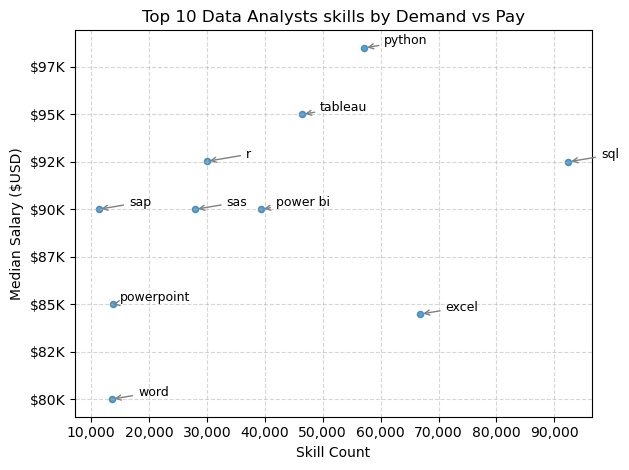

In [22]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

# Explode the list of skills into individual rows
df_DA_explode = df_DA.explode('job_skills')

# Group by the skills and calculate count and median salary
df_DA_explode = df_DA_explode.groupby('job_skills').agg(
    Skill_count=('job_skills', 'count'),
    Median_Salary=('salary_year_avg', 'median')
)
# Sorting (Matching the exact name 'Skill_Count')
df_DA_explode = df_DA_explode.sort_values(by='Skill_count', ascending=False).head(10)

df_DA_explode.plot(kind='scatter' , x='Skill_count', y='Median_Salary', alpha=0.7)

for i, txt in enumerate(df_DA_explode.index):
    plt.annotate(
        txt,
        (df_DA_explode['Skill_count'].iloc[i], df_DA_explode['Median_Salary'].iloc[i]),
    textcoords='offset points',
    xytext = (30,2.5),
    ha = 'center',
    fontsize = 9,
    arrowprops=dict(arrowstyle='->', color='gray')
)

ax = plt.gca()

from matplotlib.ticker import FuncFormatter
# 3. Define the formatters
# Y-axis: formats 100000 as $100K
def y_axis_formatter(x, pos):
    return f'${int(x/1000)}K'

# X-axis: adds a thousand separator (e.g., 90,000)
def x_axis_formatter(x, pos):
    return f'{int(x):,}'

# 4. Apply formatters to the axes
ax.yaxis.set_major_formatter(FuncFormatter(y_axis_formatter))
ax.xaxis.set_major_formatter(FuncFormatter(x_axis_formatter))

plt.xlabel('Skill Count')
plt.ylabel('Median Salary ($USD)')
plt.title('Top 10 Data Analysts skills by Demand vs Pay')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()